In [ ]:
!pip install black[jupyter] --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.0 MB/s eta 0:00:00


In [ ]:
import os
import multiprocessing
import zipfile
import json
import re
import nltk
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from tqdm import tqdm

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("gutenberg")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [ ]:
!black "/content/drive/My Drive/Colab Notebooks/AritraMCS202304_Assignment01.ipynb"

reformatted /content/drive/My Drive/Colab Notebooks/AritraMCS202304_Assignment01.ipynb

All done! ✨ 🍰 ✨
1 file reformatted.


In [ ]:
# Get the number of CPU cores
num_cores = os.cpu_count() or multiprocessing.cpu_count()

print(f"Number of CPU cores: {num_cores}")

Number of CPU cores: 2


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
working_dir = "/content/text-content/"

os.makedirs(working_dir, exist_ok=True)

with zipfile.ZipFile("/content/drive/My Drive/pdf_json.zip", "r") as zip_ref:
    zip_ref.extractall(working_dir)

os.chdir(os.path.join(working_dir, "pdf_json"))

In [ ]:
files_list = os.listdir()
json_files = [f for f in files_list if os.path.isfile(f) and f.endswith('.json')]

In [ ]:
def read_json_recursive(data) -> str:
    accumulator = ""
    if isinstance(data, dict):
        for value in data.values():
            accumulator += " " + read_json_recursive(value)
    elif isinstance(data, list):
        for item in data:
            accumulator += " " + read_json_recursive(item)
    elif isinstance(data, str):
        accumulator += str(data)
    return accumulator

In [ ]:
# Initialize an empty list of corpus
corpus_list = []

for file in tqdm(json_files[:2400]):
    with open(file, "r") as file:
        content = json.load(file)
        text_content = read_json_recursive(content)
        corpus_list.append(text_content)

# Join all coppus into a single corpus
corpora = " ".join(corpus_list)

100%|██████████| 2400/2400 [00:06<00:00, 343.24it/s]


In [ ]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    words = word_tokenize(text)
    words = [ps.stem(word) for word in words if word not in stop_words]
    return words


# Apply preprocessing to the entire corpus
processed_corpus = preprocess_text(corpora)

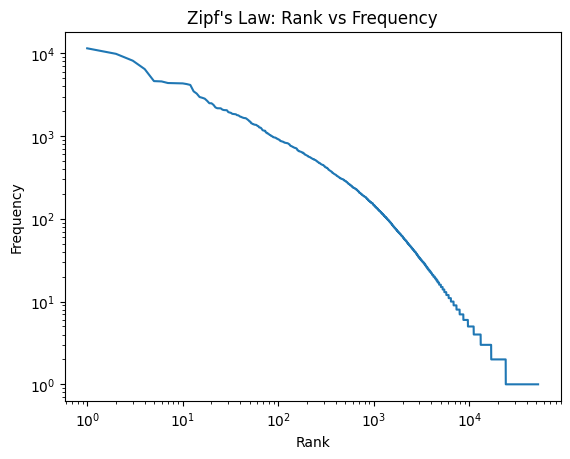

Value of α: -1.2781790885889968


In [ ]:
term_freq = Counter(processed_corpus)

ranked_terms = term_freq.most_common()

ranks = np.arange(1, len(ranked_terms) + 1)
frequencies = np.array([freq for _, freq in ranked_terms])

plt.loglog(ranks, frequencies)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law: Rank vs Frequency")
plt.show()

alpha = np.polyfit(np.log(ranks), np.log(frequencies), 1)[0]
print(f"Value of α: {alpha}")

In [ ]:
# Number of tokens
num_tokens = len(processed_corpus)

# Vocabulary size
vocab_size = len(set(processed_corpus))

print(f"Number of tokens: {num_tokens}")
print(f"Vocabulary size: {vocab_size}")

Number of tokens: 796663
Vocabulary size: 52358


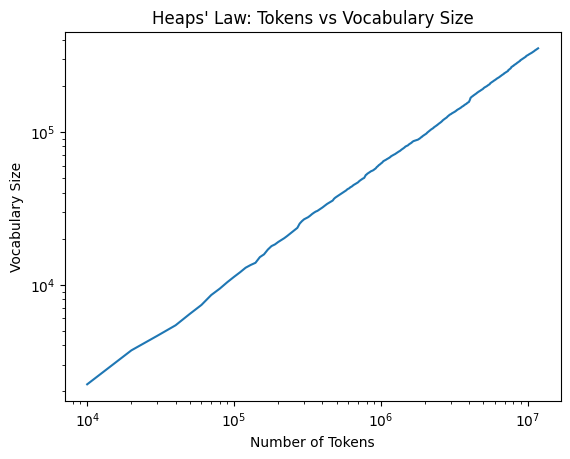

In [ ]:
vocab_count = []
tokens_count = []

# Track vocabulary size for every 10,000 tokens
for i in range(10000, num_tokens + 1, 10000):
    tokens_slice = processed_corpus[:i]
    vocab_slice = len(set(tokens_slice))
    tokens_count.append(i)
    vocab_count.append(vocab_slice)

# Plot Tokens vs Vocabulary graph
plt.plot(tokens_count, vocab_count)
plt.xlabel("Number of Tokens")
plt.ylabel("Vocabulary Size")
plt.title("Heaps' Law: Tokens vs Vocabulary Size")
plt.xscale("log")
plt.yscale("log")
plt.show()

# Trials:

In [ ]:
# print(json.dumps(content, indent=2, sort_keys=True))

In [ ]:
import nltk
from nltk.probability import FreqDist
from nltk.corpus import stopwords
import pandas as pd

stop_words = set(stopwords.words("english"))
# read the corpus
words = nltk.Text(nltk.corpus.gutenberg.words("bryant-stories.txt"))
# convert to small letters
words = [word.lower() for word in words if word.isalpha()]
words = [word.lower() for word in words if word not in stop_words]
# Get the frequency distribution of words
freq_dist = FreqDist(words)
# Heading for the results table
heading = ["Word", "Frequency"]
tf_list = []
for x, v in freq_dist.most_common(10):
    tf_list.append((x, v))
print(pd.DataFrame(tf_list, columns=heading))
# Weighted term freequency
heading = ["Word", "Weighted Frequency"]
tf_list = []
for x, v in freq_dist.most_common(10):
    tf_list.append((x, v / len(freq_dist)))
print(pd.DataFrame(tf_list, columns=heading))

     Word  Frequency
0  little        597
1    said        453
2    came        191
3     one        183
4   could        158
5    king        141
6    went        122
7   would        112
8   great        110
9     day        107
     Word  Weighted Frequency
0  little            0.161876
1    said            0.122831
2    came            0.051790
3     one            0.049620
4   could            0.042842
5    king            0.038232
6    went            0.033080
7   would            0.030369
8   great            0.029826
9     day            0.029013


In [ ]:
from multiprocessing import Pool


def f(x):
    return x * x


def main():
    pool = Pool(processes=3)  # set the processes max number 3
    result = pool.map(f, range(10))
    pool.close()
    pool.join()
    print(result)
    print('end')


if __name__ == "__main__":
    main()

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
end
